In [38]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric

In [39]:
from salishsea_tools import evaltools as et

In [40]:
df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/dfo-2023-2024-oxygen.csv',parse_dates=['time'],index_col=False)
df = df[df['DOXYZZ01']>0]
df = df[df['depth']>0].reset_index(drop=True)

df = df.rename(columns={"latitude": "Lat", "longitude": "Lon",'time':'dtUTC','depth':'Z'})
df['dtUTC'] = df['dtUTC'].dt.tz_localize(None)

In [41]:
path = '/results2/SalishSea/nowcast-green.202111'
filemap={'dissolved_oxygen':'biol_T'}

fdict={'biol_T':1}
path = f'/data/jvalenti/SHEM'
mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

start_date = dt.datetime(2023,1,1) 
end_date = dt.datetime(2023,12,31) 

In [42]:
# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# data.to_csv('O2_2023_SHEM.csv')

# path = '/results2/SalishSea/nowcast-green.202111'
# filemap={'dissolved_oxygen':'chem_T'}
# fdict={'chem_T':1}
# mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'
# start_date = dt.datetime(2023,1,1) 
# end_date = dt.datetime(2023,12,31)
# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('O2_2023_20211.csv')

# path = '/ocean/atall/MOAD/Model/202410b/oxygen/'
# filemap={'dissolved_oxygen':'chem_T'}
# fdict={'chem_T':24}
# mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'
# start_date = dt.datetime(2023,1,1) 
# end_date = dt.datetime(2023,12,31)
# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('O2_2023_202410.csv')

In [43]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()

    return rmse_val, bias,WI

In [44]:
##Combine all versions in single file
# data= pd.read_csv('O2_2023_SHEM.csv')
# data = data.rename(columns={'mod_dissolved_oxygen':'SHEM'})
# data2= pd.read_csv('O2_2023_20211.csv')
# data['v202111']=data2['mod_dissolved_oxygen']
# data3= pd.read_csv('O2_2023_202410.csv')
# data['v202410']=data3['mod_dissolved_oxygen']

# data.to_csv('O2_2023_all.csv')

In [45]:
data= pd.read_csv('O2_2023_all.csv')

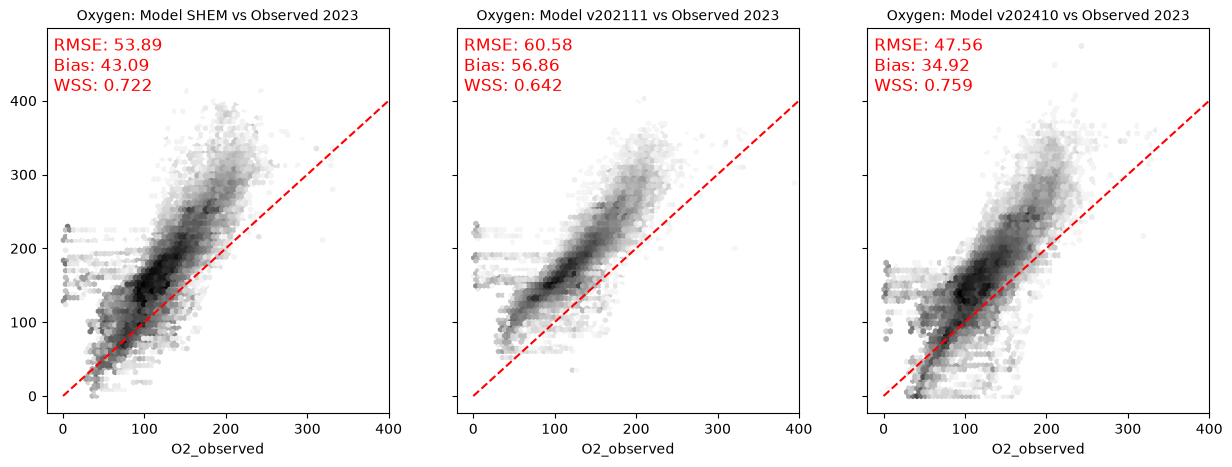

In [46]:
import matplotlib

def plot_o2(ax,data,name = "SHEM"):
    model = np.array(data[name])
    obs = np.array(data['DOXYZZ01'])*31.25
    mask_N = (obs > 0) & (~np.isnan(model))
    rmse, bias, WI = calculate_rmse_bias(obs[mask_N], model[mask_N])

    ax.hexbin(obs[mask_N], model[mask_N],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap='Greys')
    ax.set_xlabel('O2_observed')
    ax.set_title(f'Oxygen: Model {name} vs Observed 2023')

    ax.plot(np.linspace(0, 400),np.linspace(0, 400),'r--')
    ax.text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=ax.transAxes,color='red')
    ax.set_xlim(-20,400)

fig,axs = plt.subplots(1,3,figsize=(15,5),sharey=True)
plot_o2(axs[0],data,'SHEM')
plot_o2(axs[1],data,'v202111')
plot_o2(axs[2],data,'v202410')

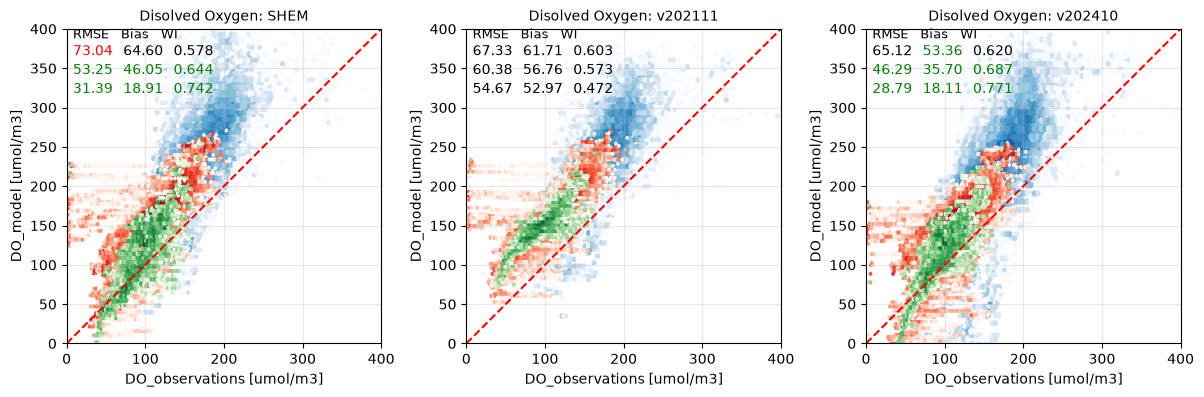

In [52]:
runs = ['SHEM','v202111','v202410']

colors = {"Shallow": "blue", "Intermediate": "orange", "Deep": "green"}
cmaps = {"Shallow": "Blues", "Intermediate": "Reds", "Deep": "Greens"}

depth_limits = [(0, 50), (50, 200), (200, np.inf)]
depth_labels = ["Shallow", "Intermediate", "Deep"]
tol = 0.05 #5%per

# Load once
dft = data
obs, depth = dft['DOXYZZ01']*31.25, dft['Z']

def get_stats(model, mask):
    return calculate_rmse_bias(obs[mask], model[mask]) if mask.any() else (np.nan, np.nan, np.nan)

base = dft['v202111']
mask_base = (base != 0) & (~obs.isna()) & (~base.isna())
baseline_stats = [
    get_stats(base, mask_base & depth.between(dmin, dmax, inclusive='left'))
    for dmin, dmax in depth_limits
]

fig, axs = plt.subplots(4, 5, figsize=(20, 20))
axs = axs.flatten()

for i, name in enumerate(runs):
    ax = axs[i]
    model = dft[name]
    mask = (model != 0) & (~obs.isna()) & (~model.isna())

    stats = []

    for (label, (dmin, dmax)), (base_rmse, base_bias, base_wi) in zip(zip(depth_labels, depth_limits), baseline_stats):
        dm = mask & depth.between(dmin, dmax, inclusive='left')
        rmse, bias, wi = get_stats(model, dm)

        #ax.scatter(obs[dm],model[dm], color=colors[label], alpha=0.6, label=label)
        ax.hexbin(obs[dm], model[dm],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap=cmaps[label])

        better_rmse = abs(rmse) <= abs(base_rmse) - abs(tol*base_rmse) 
        better_bias = abs(bias) <= abs(base_bias) - abs(tol*base_bias) 
        better_WI = wi >= base_wi + tol*base_wi 

        stats.append((rmse, bias, wi,
            "green" if better_rmse else("black" if abs(rmse) <= abs(base_rmse) + abs(tol*base_rmse) else "red") ,
            "green" if better_bias else("black" if abs(bias) <= abs(base_bias) + abs(tol*base_bias) else "red") ,
            "green" if better_WI else("black" if wi >= base_wi - tol*base_wi else "red")
        ))

    max_val = 400
    ax.plot([0, max_val], [0, max_val], 'r--')
    ax.set(xlim=(0, max_val), ylim=(0, max_val), aspect='equal',
           title=f'Disolved Oxygen: {name}', xlabel='DO_observations [umol/m3]', ylabel='DO_model [umol/m3]')

    #if i == 0:
        #ax.legend(loc=4)

    # --- Stats text ---
    ax.text(0.02, 0.97, "RMSE   Bias   WI", transform=ax.transAxes, fontsize=9)

    for k, (rmse, bias, wi, c1, c2, c3) in enumerate(stats):
        y = 0.95 - 0.06 * k
        rmse_txt = "—" if np.isnan(rmse) else f"{rmse:.2f}"
        bias_txt = "—" if np.isnan(bias) else f"{bias:.2f}"
        wi_txt = "—" if np.isnan(wi) else f"{wi:.3f}"

        ax.text(0.02, y, rmse_txt, color=c1, transform=ax.transAxes, va='top')
        ax.text(0.18, y, bias_txt, color=c2, transform=ax.transAxes, va='top')
        ax.text(0.34, y, wi_txt, color=c3, transform=ax.transAxes, va='top')

    ax.grid(alpha=0.3)

# Clean unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()